In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from cellina import CellinaGCN as CellinaModel

In [6]:
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

In [3]:
work_folder = '/g/stegle/spiljak/cellina_tutorial'

In [24]:
import sys

sys.path.append('../../scripts')

In [8]:
sys.path.append(f'{work_folder}/cellina-reproducibility/notebooks/application')

In [ ]:
from helpers import _normalize_counts, safe_log2_fold_change, compute_correlations, subsample_adata

In [27]:
sys.path.append(f'{work_folder}/cellina-reproducibility/scripts')

In [28]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
DATA_ROOT = os.environ.get("DATA_ROOT", ".")
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

#from cellina_graph import CellinaModel
from utils import set_seed
from train_loo import preprocess_adata

In [29]:
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 50


In [3]:
import cellina

In [4]:
print(cellina.__version__)

1.0.0


# Get dataset

In [30]:
set_seed(0)

In [31]:
slide_id = '242'

Typically here went preprocess adata, but apparently that wasnt proper way so here we use Load_crc_data

In [ ]:
sys.path.append(f"{work_folder}/cellina-reproducibility/scripts")
from scripts.perturb_utils import load_crc_slide
adata = load_crc_slide(slide_id=slide_id)        

In [18]:
adata #notice that there is sptail in obsm

AnnData object with n_obs × n_vars = 420694 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [33]:
adata.obs.coarse_type.value_counts()

coarse_type
Epithelial       297151
Fibroblast        44426
Plasma_cell       26743
T_cell            17908
Myeloid           15222
Smooth_muscle      8350
Endothelial        7506
Mast_cell          3388
Name: count, dtype: int64

In [ ]:
from cellina._spatial_utils import spatial_neighbors

spatial_neighbors(adata, bandwidth=100, max_neighbours=20, standardize=False, ) #adds spatial_connectivites   ? this version doesn't support um_neighbours=[-1]

In [36]:
labels_key = 'coarse_type'
domains_key = 'typ_clean'
batch_key = 'sid'

In [71]:
fig_save_path = f"{work_folder}/data/models/mark3/242/figures"

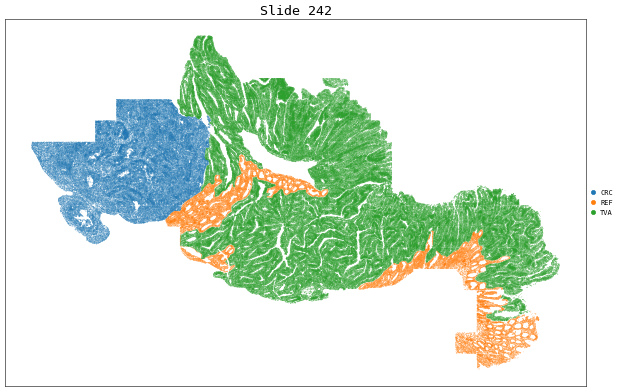

In [72]:
fig, ax = plt.subplots(figsize=(15, 15))  # width x height in inches

sc.pl.spatial(
    adata,
    color=domains_key,
    ax=ax,
    spot_size=100,
    title=f"Slide 242",
    show=False,
)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}slide.png", bbox_inches='tight')

## Data splits

In [40]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_ct = "Fibroblast"
    is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
    is_holdout_ct = adata.obs[labels_key] == holdout_ct

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [41]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [42]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

# Train

In [56]:
model_base_path = f"{work_folder}/data/models/mark3/{slide_id}"

In [ ]:
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping

model_args = {
    'adata': adata,
    'n_latent': 64,
    'n_layers': 3,
    'use_observed_lib_size': True,
    'condition_on_intrinsic': False,
    'gene_likelihood': 'nb',
    'classifier_lambda': 1.,
    'discriminator_lambda': 1.,
    'link_'
    }
train_args = {'max_epochs': 20,
              'batch_size': 2048,
              'check_val_every_n_epoch': 1,
              'early_stopping': True,
              'devices': [0],
              'datasplitter_kwargs': {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              'enable_checkpointing':True,
              'callbacks': [
                  SaveCheckpoint(
                      monitor='vae_loss_validation',
                      dirpath=f"{model_base_path}",
                      load_best_on_end=True,
                      ),
                  EarlyStopping(
                      monitor="vae_loss_validation",
                      patience=5,
                      mode="min",
                    ),
                ],
    }

plan_kwargs = {
    'lr': 1e-3,
    'normalize_losses': True
    }

In [54]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_connectivities_key="spatial_connectivities",
                           layer='counts')

/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [55]:
model = CellinaModel(
    **model_args, 
)
model.train(**train_args, plan_kwargs=plan_kwargs)

INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/cellina-g ...
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /g/stegle/spiljak/cellina_tutorial/data/models/mark1/242 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [7]
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgr

Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


INFO     File                                                                                                      
         /g/stegle/spiljak/cellina_tutorial/data/models/mark1/242/epoch=19-step=6346-vae_loss_validation=612.637207
         03125/model.pt already downloaded                                                                         


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = 

# Inference and clustering

In [57]:
checkpoint_name = "epoch=19-step=6346-vae_loss_validation=612.63720703125"
print(checkpoint_name)

epoch=19-step=6346-vae_loss_validation=612.63720703125


In [60]:
print(model_base_path)

/g/stegle/spiljak/cellina_tutorial/data/models/mark3/242


In [62]:
import os
checkpoint_name = os.listdir(f"{model_base_path}")[0]
model = CellinaModel.load(
    #f'{work_folder}/data/models/mark2/242/{checkpoint_name}/', #f"{model_base_path}/{checkpoint_name}",
        '/g/stegle/spiljak/cellina_tutorial/data/models/mark3/242/epoch=19-step=6346-vae_loss_validation=612.63720703125/', #f"{model_base_path}/{checkpoint_name}", --- IGNORE ---
        adata=adata,
)


INFO     File                                                                                                      
         /g/stegle/spiljak/cellina_tutorial/data/models/mark3/242/epoch=19-step=6346-vae_loss_validation=612.637207
         03125/model.pt already downloaded                                                                         


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


In [64]:
adata.obsm['cellina_basal'] = model.get_latent_representation(adata=adata, latent_key='z', batch_size=2048)
adata.obsm['cellina_spatial'] = model.get_latent_representation(adata=adata, latent_key='s', batch_size=2048)
# adata.obsm['cellina_latent'] = model.get_latent_representation(adata=adata, batch_size=4096)

### Latent visualization

In [65]:
adata_sub = subsample_adata(adata, fraction=0.5)


In [66]:
sc.pp.neighbors(adata_sub, use_rep='cellina_basal')
sc.tl.umap(adata_sub)

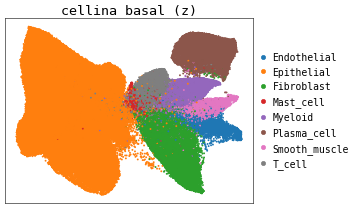

In [73]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, size=30, legend_fontsize=14, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/crc_{slide_id}_umap_basal_ct.png", bbox_inches='tight')

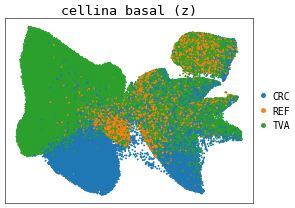

In [74]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, size=30, legend_fontsize=14, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/crc_{slide_id}_umap_basal_niche.png", bbox_inches='tight')

In [75]:
sc.pp.neighbors(adata_sub, use_rep='cellina_spatial')
sc.tl.umap(adata_sub)

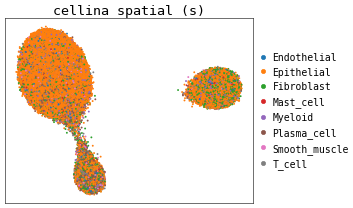

In [76]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, size=30, legend_fontsize=14, show=False, title="cellina spatial (s)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_ct.png", bbox_inches='tight')

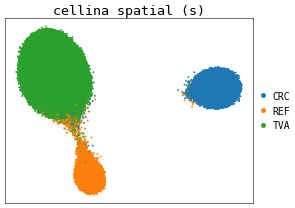

In [77]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, size=30, legend_fontsize=14, show=False, title="cellina spatial (s)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_niche.png", bbox_inches='tight')

## Hotspot clusters

In [78]:
import pandas as pd
import decoupler as dc
import hotspot


import sys, importlib

# Remove cached version of the installed plotting package
if 'plotting' in sys.modules:
    del sys.modules['plotting']

# Insert at front so it takes priority over site-packages
sys.path.insert(0, f'{work_folder}/cellina-reproducibility/scripts')
from plotting import plot_custom_umap

In [95]:
adata_crc = adata[adata.obs[domains_key].str.contains('CRC')].copy()

In [96]:
set_seed(0)  # ensure reproducible hotspot KNN and module detection

In [97]:
hs = hotspot.Hotspot(
    adata_crc,
    layer_key="counts",
    model='danb',
    latent_obsm_key="cellina_spatial",
    umi_counts_obs_key="nCount_RNA"
)

hs.create_knn_graph(
    weighted_graph=False, n_neighbors=30,
)

In [98]:
hs_results = hs.compute_autocorrelations(jobs=24) #computes Morans's I for each LATENT dimension, paralelized across 24 cores

100%|██████████| 3000/3000 [00:07<00:00, 423.56it/s]


In [99]:
# Select the genes with significant autocorrelation, only the top 5%
top_k = 1200
hs_genes = hs_results.loc[hs_results.FDR < 0.05].head(top_k).index

In [100]:
# Compute pair-wise local correlations between these genes
load_lcz = False
base_dir = f'{model_base_path}/{slide_id}'
lcz_path = f'{base_dir}/hotspot_lcz_crc.csv'

if load_lcz:
    lcz = pd.read_csv(lcz_path, index_col=0)
    hs.local_correlation_z = lcz
else:
    lcz = hs.compute_local_correlations(hs_genes, jobs=24)
    os.makedirs(base_dir, exist_ok=True)
    lcz.to_csv(lcz_path)

Computing pair-wise local correlation on 386 features...


100%|██████████| 74305/74305 [01:53<00:00, 652.83it/s]


In [ ]:
modules = hs.create_modules(min_gene_threshold=50, core_only=True, fdr_threshold=0.05) #original min_gene_threshold=100, but kept getting only one module, which is not very interesting for downstream analysis

In [ ]:
module_scores = hs.calculate_module_scores() 

module_scores.head()

Computing scores for 2 modules...


100%|██████████| 2/2 [00:03<00:00,  1.66s/it]


,1,2
c_4_34_269,1.509974,-0.526587
c_4_34_290,0.260101,-0.314491
c_4_34_296,0.784604,-0.769566
c_4_34_308,2.037122,0.093184
c_4_34_322,-1.756254,0.093362


In [105]:
module_cols = []
for c in module_scores.columns:
    key = f"Module {c}"
    adata_crc.obs[key] = module_scores[c]
    module_cols.append(key)

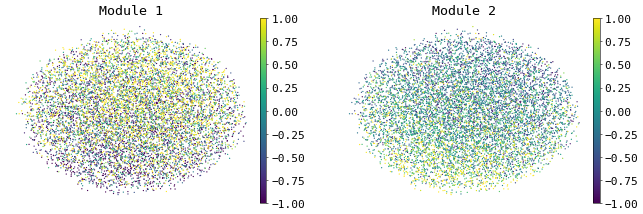

In [106]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=module_cols,frameon=False, vmin=-1, vmax=1, wspace=0.2
)

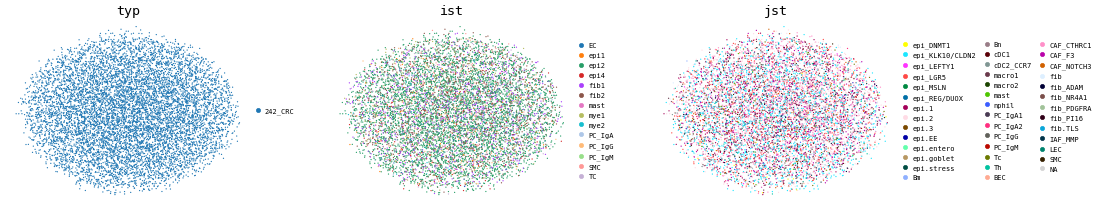

In [107]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=['typ', 'ist', 'jst'], frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [108]:
module_scores_epi = module_scores.loc[adata_crc.obs_names]

In [109]:
adata_crc.obsm['module_scores'] = module_scores_epi.values

In [110]:
top_modules = module_scores.idxmax(axis=1)

# Add to adata.obs
adata_crc.obs["top_module"] = top_modules.astype(str)
adata_crc.obs["top_module"] = adata_crc.obs["top_module"].astype("category")

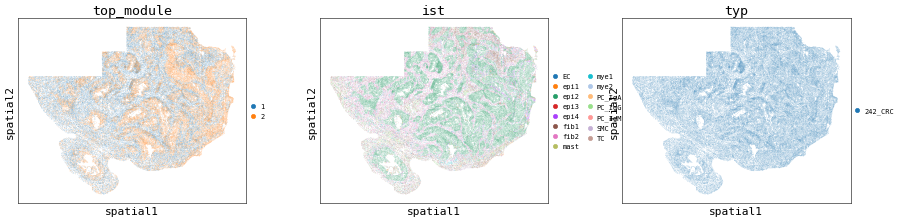

In [111]:
# Plot
sc.pl.spatial(
    adata_crc,
    color=["top_module", "ist", "typ"],
    palette=None,
    spot_size=50,
    show=True
)

In [112]:
# top module to f{CRC{}}
adata_crc.obs['microenvironment'] = adata_crc.obs['top_module'].apply(lambda x: f"CRC{x}")

In [113]:
adata_crc.obs['microenvironment'].value_counts()

microenvironment
CRC1    45137
CRC2    44771
Name: count, dtype: int64

### Remap

In [114]:
typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata_sub.obs_names)  # NaN for non-CRC cells

adata_sub.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata_sub.obs['typ'].astype(str))
)

typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata.obs_names)  # NaN for non-CRC cells
adata.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata.obs['typ'].astype(str))
)
    

In [115]:
adata.obs['microenvironment'].value_counts()

microenvironment
242_TVA    286784
CRC1        45137
CRC2        44771
242_REF     44002
Name: count, dtype: int64

/scratch/jobs/55312762/ipykernel_315572/333694513.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')


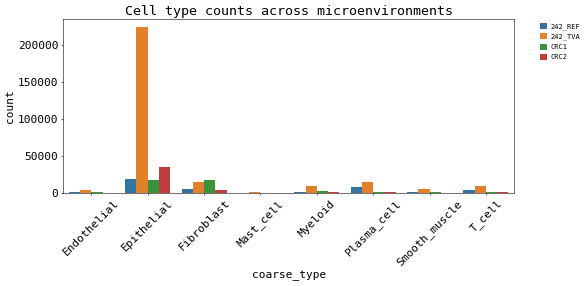

In [116]:
# Plot how many cells of each microenvironment are present in each cell type
celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=celltype_microenv_counts, x=labels_key, y='count', hue='microenvironment')
plt.xticks(rotation=45)
plt.title("Cell type counts across microenvironments")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Counterfactuals - CRC_global vs. CRC_microenv

In [120]:
celltypes = ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in m]
results = {k: adata[adata.obs[labels_key] == k] for k in celltypes}

In [122]:
print(microenvironments)

['CRC1', 'CRC2']


In [123]:
for ct, ds in results.items():
    print(ct, ds.n_obs)

Endothelial 7506
Epithelial 297151
Fibroblast 44426
Myeloid 15222
T_cell 17908


In [124]:
print(adata.obs[labels_key].unique())

['Fibroblast', 'Myeloid', 'Epithelial', 'T_cell', 'Smooth_muscle', 'Endothelial', 'Plasma_cell', 'Mast_cell']
Categories (8, object): ['Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']


In [125]:
import gc, torch
  
for ct in tqdm(celltypes, desc="Cell types"):
    # ... your existing loop ...

    # add at the end of each ct iteration:
    torch.cuda.empty_cache()
    gc.collect()

Cell types: 100%|██████████| 5/5 [00:01<00:00,  2.73it/s]


In [127]:
import pickle

In [128]:
dirname = f"{work_folder}/data/trained_adata/mark3"
adata.write_h5ad(f"{dirname}/checkpoint_adata.h5ad")
model.save(f"{dirname}/checkpoint_model/", overwrite=True)
  
with open(f"{dirname}/checkpoint_meta.pkl", 'wb') as f:
    pickle.dump({'celltypes': celltypes, 'microenvironments': microenvironments, 'domains_key': domains_key, 'labels_key': labels_key}, f)

In [ ]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
DATA_ROOT = os.environ.get("DATA_ROOT", ".")
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

import sys
sys.path.append(f'{work_folder}/cellina-reproducibility/scripts')
from utils import set_seed
from train_loo import preprocess_adata

sys.path.append(f'{work_folder}/cellina-reproducibility/notebooks/application')
from helpers import _normalize_counts, safe_log2_fold_change, compute_correlations, subsample_adata

In [11]:
import pickle, anndata, os
#from cellina_graph import CellinaModel
from cellina import CellinaGCN as CellinaModel

dirname = f"{work_folder}/data/trained_adata/mark3"
if os.path.exists(f'{dirname}/checkpoint_adata.h5ad'):
    adata = anndata.read_h5ad(f'{dirname}/checkpoint_adata.h5ad')
    model = CellinaModel.load(f'{dirname}/checkpoint_model/', adata=adata)
    with open(f'{dirname}/checkpoint_meta.pkl', 'rb') as f:
        meta = pickle.load(f); celltypes = meta['celltypes']; microenvironments = meta['microenvironments']
        domains_key = meta['domains_key']; labels_key = meta['labels_key']
    print("Loaded from checkpoint — skipping setup")

#results = {k: adata[adata.obs[labels_key] == k] for k in celltypes}
results = {k: subsample_adata(ds, fraction=0.1) for k, ds in results.items()} #subsampling data
rng = np.random.default_rng(0)

INFO     File /g/stegle/spiljak/cellina_tutorial/data/trained_adata/mark3/checkpoint_model/model.pt already        
         downloaded                                                                                                


/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/cellina_e ...
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary

INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction
Loaded from checkpoint — skipping setup


In [6]:
import cellina
print(cellina.__version__)

1.0.0


In [10]:
import os
import torch
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    is_celltype = adata.obs[labels_key].astype(str) == ct
    
    mask_control = ~is_tumor_region & is_celltype
    # mask_control = adata.obs[domains_key].astype(str).str.contains('REF', regex=True) & is_celltype # NOTE: changed from ~CRC to REF
    
    idx_control = np.where(mask_control.values)[0]

    # 1. Compute counterfactuals for global crc -- Claude thinks this causes Out Of Memory crash each time so he suggested a bleow part to fix it, we will se
    #mask_target = is_tumor_region
    #idx_target = np.where(mask_target.values)[0] #mask_target = is_tumor_region & is_celltype
    
    # 1. Compute counterfactuals for global crc
    mask_target = is_tumor_region
    idx_target = np.where(mask_target.values)[0]
    print(len(idx_control), len(idx_target))

    rng = np.random.default_rng(0)
    
    torch.cuda.empty_cache() #my addititon

    args = {
                
                # "adata": adata,
                "indices": idx_control,
                "neighbour_indices": idx_target,
                "batch_size": 256,
                "seed": 0,
                'n_neighbors_per_seed':20
            }
    results[ct].obsm['recon_x'] = model.get_normalized_expression(adata=results[ct], batch_size=256, library_size=1e4)
    results[ct].uns[f'counterfactual_x_global'] = model.get_counterfactual_expression(**args, library_size=1e4)
    results[ct].uns[f'counterfactual_latents_global'] = model.get_counterfactual_latents(**args, latent_key='shifted')
    model.module.to('cuda')
    
    # 2. Loop over microenvironments
    for microenv in tqdm(microenvironments, desc=f"Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        mask_target = is_in_microenv
        #mask_target = is_in_microenv & is_celltype
        idx_target = np.where(mask_target.values)[0]
        args["neighbour_indices"] = idx_target
        results[ct].uns[f'counterfactual_x_{microenv}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{microenv}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

Cell types:   0%|                                                                                                                                                                                                                                                            | 0/5 [00:00<?, ?it/s]

/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


5864 89908


/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
Cell types:  20%|████████████████████████████████████████████████▌                                                                                                                                                                                                  | 1/5 [02:36<10:24, 156.15s/it]/g/stegle/spiljak/progr

243838 89908


Cell types:  20%|████████████████████████████████████████████████▌                                                                                                                                                                                                  | 1/5 [05:39<22:37, 339.48s/it]


KeyboardInterrupt: 

In [12]:
#isti racku ali original, bez mojih kerefeka za popravit OOM error
for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    is_celltype = adata.obs[labels_key].astype(str) == ct
    
    mask_control = ~is_tumor_region & is_celltype
    # mask_control = adata.obs[domains_key].astype(str).str.contains('REF', regex=True) & is_celltype # NOTE: changed from ~CRC to REF
    
    idx_control = np.where(mask_control.values)[0]

    # 1. Compute counterfactuals for global crc
    mask_target = is_tumor_region
    #mask_target = is_tumor_region & is_celltype
    idx_target = np.where(mask_target.values)[0]
    args = {
                #"adata": adata,
                "indices": idx_control,
                "neighbour_indices": idx_target,
                "batch_size": 1024,
                "seed": 0,
            }
    results[ct].obsm['recon_x'] = model.get_normalized_expression(adata=results[ct], batch_size=1024, library_size=1e4)
    results[ct].uns[f'counterfactual_x_global'] = model.get_counterfactual_expression(**args, library_size=1e4)
    results[ct].uns[f'counterfactual_latents_global'] = model.get_counterfactual_latents(**args, latent_key='shifted')

    # 2. Loop over microenvironments
    for microenv in tqdm(microenvironments, desc=f"Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        mask_target = is_in_microenv
        #mask_target = is_in_microenv & is_celltype
        idx_target = np.where(mask_target.values)[0]
        args["neighbour_indices"] = idx_target
        results[ct].uns[f'counterfactual_x_{microenv}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{microenv}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

Cell types:   0%|          | 0/5 [00:00<?, ?it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler =

/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
Cell types:  20%|██        | 1/5 [00:45<03:00, 45.18s/it]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSam

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSam

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(
/g/stegle/spiljak/programs/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSam

In [ ]:
# _normalize_counts, safe_log2_fold_change, compute_correlations imported from helpers (cell 2)


In [13]:
summary = []
deg = 200

for ct, dataset in tqdm(results.items(), desc="Computing correlations"):
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    mask_control = ~dataset.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    # mask_control = dataset.obs[domains_key].astype(str).str.contains('REF', regex=True) # NOTE: change from ~CRC to REF?

    control = dataset.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    is_ct = dataset.obs[labels_key].astype(str) == ct
    #mask_target = is_tumor_region & is_ct
    mask_target = is_tumor_region
    target = adata.layers['counts'].todense()[mask_target]
    target = np.asarray(target)

    counterfactual = dataset.uns['counterfactual_x_global']
    pear_global, spear_global = compute_correlations(control, target, counterfactual, deg=deg)

    summary.append({
        "cell_type": ct,
        "label": "CRC_global",
        "pearson": np.round(pear_global, 4),
        "spearman": np.round(spear_global, 4)
    })

    for microenv in tqdm(microenvironments, desc="Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        
        #mask_target = is_in_microenv & is_ct
        mask_target = is_in_microenv
        target = adata.layers['counts'].todense()[mask_target]

        target = np.asarray(target)
        counterfactual = dataset.uns[f'counterfactual_x_{microenv}']
        pear_microenv, spear_microenv = compute_correlations(control, target, counterfactual, deg=deg)
        summary.append({
            "cell_type": ct,
            "label": microenv,
            "pearson": np.round(pear_microenv, 4),
            "spearman": np.round(spear_microenv, 4)
        })

Computing correlations: 100%|██████████| 5/5 [01:29<00:00, 17.87s/it]


In [14]:
summary_df = pd.DataFrame(summary)

In [15]:
print(summary_df)

      cell_type       label  pearson  spearman
0   Endothelial  CRC_global   0.8708    0.6629
1   Endothelial        CRC1   0.9078    0.7380
2   Endothelial        CRC2   0.8225    0.6142
3    Epithelial  CRC_global   0.9091    0.7970
4    Epithelial        CRC1   0.8943    0.8061
5    Epithelial        CRC2   0.9557    0.8862
6    Fibroblast  CRC_global   0.6921    0.5988
7    Fibroblast        CRC1   0.7778    0.7909
8    Fibroblast        CRC2   0.4224    0.3561
9       Myeloid  CRC_global   0.4557    0.3950
10      Myeloid        CRC1   0.6375    0.6134
11      Myeloid        CRC2   0.2994    0.2241
12       T_cell  CRC_global   0.7478    0.7247
13       T_cell        CRC1   0.8460    0.7934
14       T_cell        CRC2   0.6012    0.6022


In [19]:
print(work_folder)

/g/stegle/spiljak/cellina_tutorial


In [20]:
# Save df
slide_id = '242'
summary_df.to_csv(f"{work_folder}/data/counterfactual_summary_{slide_id}.csv", index=False)

## Save outputs

In [23]:
# ── Save Part 1 outputs ────────────────────────────────────────────────────
import pickle, os

os.makedirs("output", exist_ok=True)

# Save annotated AnnData (includes obsm latents + obs microenvironment)
adata.write_h5ad(f"{work_folder}/data/adata_with_microenv.h5ad")
print("Saved adata to output/adata_with_microenv.h5ad")



# Save per-cell-type results dict (AnnData objects with .uns counterfactuals)
with open("output/results.pkl", "wb") as _f:
    pickle.dump(results, _f)
print("Saved results dict to output/results.pkl")

#print(f"Model checkpoint saved at: {model_base_path}")


Saved adata to output/adata_with_microenv.h5ad
Saved results dict to output/results.pkl
